In [39]:
import pandas as pd
import numpy as np

In [40]:
df = pd.read_csv('E:/ml_project/genz-socialmedia-usage/data/genz_social_media_usage_1M.csv')

In [41]:
df.head()

,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
0,19,Male,Australia,2.658617,Snapchat,4,Education,29.222443,0,6.705830,Medium,15.779443
1,16,Female,USA,5.685387,Twitter,3,Socializing,32.464726,1,6.633111,High,47.714864
2,25,Female,India,2.782420,TikTok,2,Socializing,18.170204,1,6.035397,Medium,62.524625
3,27,Male,India,3.486598,YouTube,4,Education,22.493804,1,8.110861,Medium,31.935102
4,23,Female,India,3.748829,TikTok,1,Entertainment,27.358410,1,6.658598,Medium,29.466046


# Data Description

In [42]:
print('DataFrame Info: ')
df.info()

DataFrame Info: 
<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 12 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   age                       1000000 non-null  int64  
 1   gender                    1000000 non-null  str    
 2   country                   1000000 non-null  str    
 3   daily_usage_hours         1000000 non-null  float64
 4   primary_platform          1000000 non-null  str    
 5   num_platforms_used        1000000 non-null  int64  
 6   purpose                   1000000 non-null  str    
 7   avg_session_minutes       1000000 non-null  float64
 8   night_usage               1000000 non-null  int64  
 9   mental_health_score       1000000 non-null  float64
 10  addiction_level           1000000 non-null  str    
 11  screen_time_before_sleep  1000000 non-null  float64
dtypes: float64(4), int64(3), str(5)
memory usage: 91.6 MB


# Data Statistics

In [43]:
print('Data Statistics:')
df.describe()

Data Statistics:


,age,daily_usage_hours,num_platforms_used,avg_session_minutes,night_usage,mental_health_score,screen_time_before_sleep
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,19.994629,3.514998,2.999469,25.088819,0.599958,7.170671,40.120754
std,4.322119,1.468771,1.414598,9.794249,0.489907,1.503885,19.569847
min,13.000000,0.500000,1.000000,5.000000,0.000000,1.000000,0.000000
25%,16.000000,2.493985,2.000000,18.257267,0.000000,6.147371,26.459592
50%,20.000000,3.503302,3.000000,25.002480,1.000000,7.198098,39.977162
75%,24.000000,4.513016,4.000000,31.759257,1.000000,8.243818,53.424345
max,27.000000,10.000000,5.000000,80.262224,1.000000,10.000000,137.998719


In [44]:
print('Missing Values:')
df.isnull().sum()

Missing Values:


age                         0
gender                      0
country                     0
daily_usage_hours           0
primary_platform            0
num_platforms_used          0
purpose                     0
avg_session_minutes         0
night_usage                 0
mental_health_score         0
addiction_level             0
screen_time_before_sleep    0
dtype: int64

In [45]:
print('Missing Values(%):')
df.isnull().mean()*100

Missing Values(%):


age                         0.0
gender                      0.0
country                     0.0
daily_usage_hours           0.0
primary_platform            0.0
num_platforms_used          0.0
purpose                     0.0
avg_session_minutes         0.0
night_usage                 0.0
mental_health_score         0.0
addiction_level             0.0
screen_time_before_sleep    0.0
dtype: float64

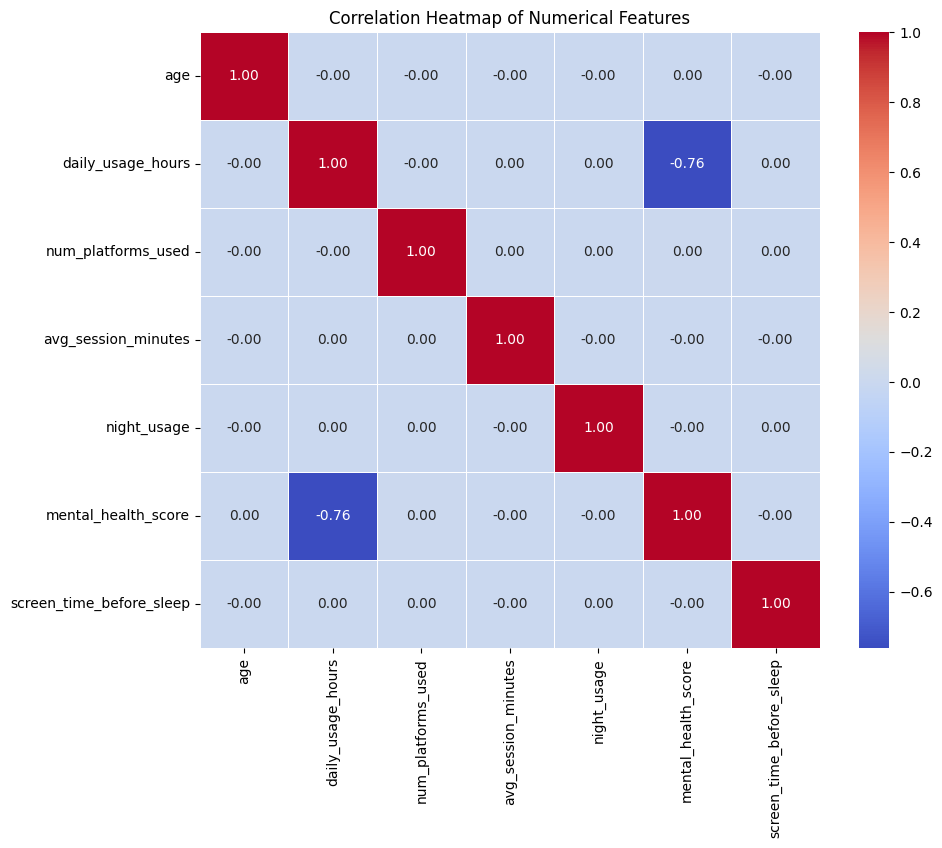

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10, 8))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)

plt.title('Correlation Heatmap of Numerical Features')

plt.show()

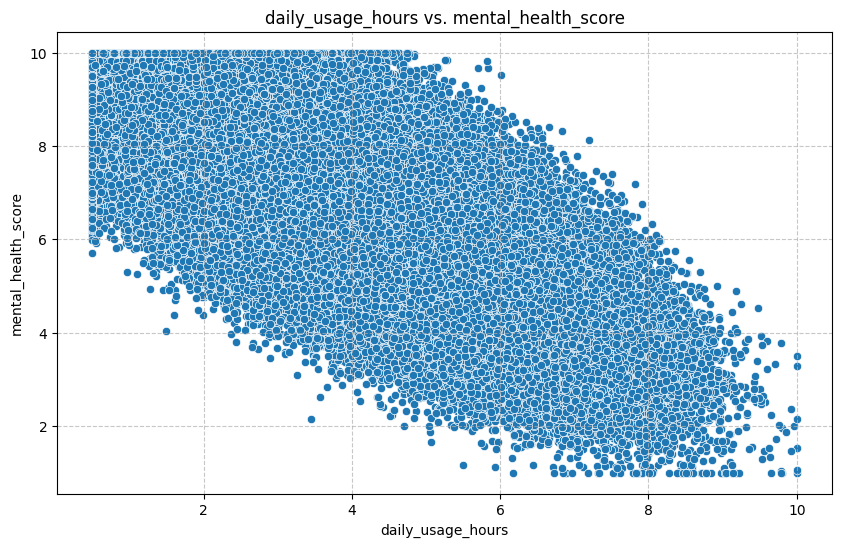

In [47]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='daily_usage_hours', y='mental_health_score', data=df)

plt.title('daily_usage_hours vs. mental_health_score')
plt.xlabel('daily_usage_hours')
plt.ylabel('mental_health_score')

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [48]:
from sklearn.model_selection import train_test_split

x = df.drop(columns=['addiction_level'])
y = df['addiction_level']

In [49]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [50]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

In [51]:
categorical_cols = x.select_dtypes(include=['object']).columns
numerical_cols = x.select_dtypes(exclude=['object']).columns

C:\Users\AYUSH GAUTAM\AppData\Local\Temp\ipykernel_27940\2954298961.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = x.select_dtypes(include=['object']).columns


In [52]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [53]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [54]:
logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

logistic_model.fit(x_train, y_train)

y_pred_log = logistic_model.predict(x_test)

In [55]:
print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy:
0.999635

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     31804
           1       1.00      1.00      1.00     50071
           2       1.00      1.00      1.00    118125

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



In [56]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

df = df.sample(20000, random_state=42)

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=20,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)

print("Random Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy:
0.999995


In [57]:
print("Random Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy:
0.999995

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     31804
           1       1.00      1.00      1.00     50071
           2       1.00      1.00      1.00    118125

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



In [58]:
import pandas as pd
import joblib

# Load model
model = joblib.load("social_media_addiction_predictor.pkl")

# New user data
new_user = pd.DataFrame({
    'age': [20],
    'gender': ['Male'],
    'country': ['India'],
    'daily_usage_hours': [7],
    'primary_platform': ['Instagram'],
    'num_platforms_used': [4],
    'purpose': ['Entertainment'],
    'avg_session_minutes': [45],
    'night_usage': [1],
    'mental_health_score': [6],
    'screen_time_before_sleep': [60]
})

prediction = model.predict(new_user)

print("Predicted Addiction Level:", prediction[0])

Predicted Addiction Level: Medium


In [59]:
import pandas as pd
import joblib

model = joblib.load("social_media_addiction_predictor.pkl")

age = int(input("Age: "))
gender = input("Gender (Male/Female): ")
country = input("Country: ")
daily_usage_hours = float(input("Daily Usage Hours: "))
primary_platform = input("Primary Platform: ")
num_platforms_used = int(input("Number of Platforms Used: "))
purpose = input("Purpose: ")
avg_session_minutes = float(input("Average Session Minutes: "))
night_usage = int(input("Night Usage (0/1): "))
mental_health_score = float(input("Mental Health Score: "))
screen_time_before_sleep = float(input("Screen Time Before Sleep: "))

user_data = pd.DataFrame({
    'age': [age],
    'gender': [gender],
    'country': [country],
    'daily_usage_hours': [daily_usage_hours],
    'primary_platform': [primary_platform],
    'num_platforms_used': [num_platforms_used],
    'purpose': [purpose],
    'avg_session_minutes': [avg_session_minutes],
    'night_usage': [night_usage],
    'mental_health_score': [mental_health_score],
    'screen_time_before_sleep': [screen_time_before_sleep]
})

prediction = model.predict(user_data)

print("\nPredicted Addiction Level:", prediction[0])

Age:  36
Gender (Male/Female):  Male
Country:  India
Daily Usage Hours:  17
Primary Platform:  Insta
Number of Platforms Used:  4
Purpose:  
Average Session Minutes:  


ValueError: could not convert string to float: ''